# Modelo 4_ETL1

Dataset: **dataset_caracteristicas_train_V1_ALL.csv**

### ***Que hacemos en este notebook?***

El **Modelo 4** es el experimento de validación más riguroso que hicimos hasta ahora. Este notebook responde a la siguiente pregunta:

> ***¿Ha aprendido el modelo a reconocer voz sintética como concepto general, o simplemente memorizó los artefactos acústicos de los ataques vistos durante el entrenamiento?***

## **En qué se diferencia este modelo de los anteriores?**

| Modelo | Estrategia de validación | Limitación principal |
|--------|--------------------------|----------------------|
| **1 y 2** | Split aleatorio estratificado (80/20) | El test contiene muestras de **todos** los ataques |
| **3** | Leave-One-Group-Out, una sola vez (A05–A06 como test) | Solo **una** iteración - resultado estadísticamente poco robusto |
| **4** | Leave-One-Group-Out Cross-Validation: **6 iteraciones**, cada ataque excluido una vez | Estimación sólida con **media y desviación estándar** sobre 6 folds independientes |

Leave-One-Group-Out (lo que hicimos en el Modelo 3) significa dejar fuera un grupo una vez. Entrenamos con A01, A02, A03, A04 y testeamos con A05 y A06. Se hace una sola vez y se obtiene un único resultado. El problema es que ese resultado puede ser buena o mala suerte dependiendo de qué grupo elegimos dejar fuera.

LOGOCV (Leave-One-Group-Out Cross-Validation), en cambio, es la versión más rigurosa del Leave-One-Group-Out. La Cross Validation que hacemos en este notebook es clave, porque estamos rotando sistemáticamente el algoritmo de IA que se queda fuera. Lo que vamos a ser es:

- Iteración 1: train con A02–A06, test con A01
- Iteración 2: train con A01, A03–A06, test con A02
- Iteración 3: train con A01, A02, A04–A06, test con A03
... y así hasta la iteración 6

Al final obtenemos 6 resultados, y de las metricas calculamos la media y la desviación estándar.

La **desviación estándar del F1 entre folds** mide la heterogeneidad entre algoritmos de ataque (o sea, si el F1 es alto, significa que el modelo no es capaz de generalizar bien cuando se encuentra con audios generados por algoritmos de IA desconocidos):

| STD del F1 | Interpretación | Implicación en producción |
|------------|---------------|--------------------------|
| **< 0.04** (baja) | Rendimiento estable entre ataques -  el modelo capturó características acústicas *universales* | Alta fiabilidad operativa |
| **0.04 – 0.08** (moderada) | Generalización parcial - algunos ataques son más difíciles de extrapolar | Requiere monitorización y re-entrenamiento periódico |
| **> 0.08** (alta) | El modelo aprendió vulnerabilidades de cada vocoder | Vulnerable ante cualquier nuevo sistema TTS de alta calidad |


### ***Que vamos a usar para este notebook?***

- **Algoritmo:** XGBoost optimizado (`XGB_OPTIMAL_PARAMS_M1`)
- **Features:** 13 features óptimas (Permutation Importance)
- **Folds:** 6 (cada ataque (A01, A02, A03, A04, A05, A06) queda fuera del entrenamiento una vez)
- **Balance:** Undersampling 1:1 en train (2 000 spoof + 2 000 bonafide) y en test

### ***Bloque 1: configuración global***

In [1]:
# Bloque 1: configuración global

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import warnings
import os
import glob as glob_module
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc as sklearn_auc
)

# Reproducibilidad 
RANDOM_STATE = 42

# Rutas de datos
DATA_TRAIN_PATH = '../../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'
DATA_EVAL_PATH  = '../../Obtencion_Metricas/dataset_caracteristicas_eval.csv'
TEST_VOCES_DIR  = '../../test_voces/'

# Lista de ataques para el bucle LOGOCV 
ATTACKS = ['A01', 'A02', 'A03', 'A04', 'A05', 'A06']

# Hiperparámetros óptimos de XGBoost (RandomizedSearchCV, Modelo 1, N=4000)
XGB_OPTIMAL_PARAMS_M1 = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'logloss',
    'use_label_encoder': False,
    'random_state'     : RANDOM_STATE,
    'n_jobs'           : -1,
    'n_estimators'     : 620,
    'max_depth'        : 7,
    'learning_rate'    : 0.09591931665418388,
    'subsample'        : 0.602208846849441,
    'colsample_bytree' : 0.6379995910112717,
    'reg_alpha'        : 0.7722447692966574,
    'reg_lambda'       : 1.3942205669037757,
    'min_child_weight' : 1,
}

# 13 features óptimas (Permutation Importance sobre XGBoost, Modelo 1)
FINAL_FEATURES = [
    'signal_mean', 'mfcc_9_std',  'mfcc_6_mean', 'mfcc_7_mean',
    'mfcc_4_std',  'mfcc_5_mean', 'mfcc_13_mean', 'mfcc_2_std',
    'mfcc_8_std',  'mfcc_3_mean', 'mfcc_10_std',  'mfcc_9_mean',
    'mfcc_11_mean'
]

# Tamaño de conjuntos balanceados
N_PER_CLASS_TRAIN = 2000   # 2000 spoof + 2000 bonafide = 4000 por fold

# Cargar dataset de train 
df = pd.read_csv(DATA_TRAIN_PATH)

print(f'Dataset cargado        : {len(df):,} registros, {len(df.columns)} columnas')
print(f'Features seleccionadas : {len(FINAL_FEATURES)} de {len(df.columns) - 3}')
print(f'Features               : {FINAL_FEATURES}')
print()
print('Distribución por attack_id:')
print(df['attack_id'].value_counts().sort_index())
print()
print('Distribución por label:')
print(df['label'].value_counts())
print()
print(f'Configuración LOGOCV: {len(ATTACKS)} folds — cada ataque (A01-A06) queda fuera una vez')
print(f'Train por fold      : {N_PER_CLASS_TRAIN*2:,} muestras ({N_PER_CLASS_TRAIN:,} spoof + {N_PER_CLASS_TRAIN:,} bonafide)')

Dataset cargado        : 25,380 registros, 37 columnas
Features seleccionadas : 13 de 34
Features               : ['signal_mean', 'mfcc_9_std', 'mfcc_6_mean', 'mfcc_7_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_13_mean', 'mfcc_2_std', 'mfcc_8_std', 'mfcc_3_mean', 'mfcc_10_std', 'mfcc_9_mean', 'mfcc_11_mean']

Distribución por attack_id:
attack_id
-      2580
A01    3800
A02    3800
A03    3800
A04    3800
A05    3800
A06    3800
Name: count, dtype: int64

Distribución por label:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64

Configuración LOGOCV: 6 folds — cada ataque (A01-A06) queda fuera una vez
Train por fold      : 4,000 muestras (2,000 spoof + 2,000 bonafide)


### ***Bloque 2: Leave One Group Out Cross Validation***

## ***Qué es Leave-One-Group-Out CV (LOGOCV) y por qué es mejor del split aleatorio?***

En un **split aleatorio estratificado** (Modelos 1 y 2), el conjunto de test contiene muestras de todos los algoritmos de ataque. Esto hace que el modelo aprende los patrones acusticos de cada ataque y luego los reconoce en el test. Los resultados parecen excelentes, pero no reflejan la realidad operativa.

En **ciberseguridad**, el escenario real es el opuesto: los sistemas defensivos se enfrentan constantemente a nuevos ataques nunca vistos. 

**LOGOCV (Leave One Group Out Cross Validation)** replica exactamente ese escenario:

| Metodologia | Split aleatorio | LOGOCV |
|---------|----------------|--------|
| **¿Qué mide?** | Capacidad de memorización | Capacidad de generalización |
| **Fuga de información** | Sí (el test tiene ataques del train) | No (test con ataques 100% nuevos) |
| **Validez en producción** | Baja | Alta |
| **Robustez estadística** | Un solo número | Media + desviación estándar sobre 6 folds |
| **Coste computacional** | Bajo | 6 veces mayor (un modelo por cada fold) |

---

### ***Cómo se construyen los conjuntos en cada iteración?***

En cada uno de los 6 folds, el ataque excluido (`fold_attack`) actúa como el atacante desconocido:

- **TEST** = todos los spoof de `fold_attack` + una fracción proporcional de bonafide;
- **TRAIN** = spoof de los **5 ataques restantes** + el resto de bonafide.


### ***Qué esperamos observar?***

- **F1 alto y estable en todos los folds + STD baja**: el modelo generaliza bien y capturó patrones acústicos comunes a todos los vocoders;

- **Algunos folds mostran caídas bruscas de F1 + STD alta**: el modelo es frágil ante ciertos ataques. Se verifica una memorización de caracteristicas específicas sin aprender el concepto de voz sintética.

In [2]:
# Bloque 2: Bucle Leave-One-Group-Out Cross-Validation

df_bonafide = df[df['label'] == 'bonafide'].copy()
df_spoof    = df[df['label'] == 'spoof'].copy()

# Mezclar bonafide una sola vez con semilla fija para que no haya solapamiento entre train y test
df_bonafide = df_bonafide.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

n_bon_total    = len(df_bonafide)
n_bon_per_fold = n_bon_total // len(ATTACKS)   # ~430 muestras bonafide por fold

fold_results = []

for i, fold_attack in enumerate(ATTACKS):

    print(f'\n{"="*65}')
    print(f'  FOLD {i+1}/{len(ATTACKS)}  |  Ataque excluido del TRAIN: {fold_attack}')
    print(f'{"="*65}')

    # TEST: todos los spoof del ataque excluido + bonafide
    test_spoof_pool = df_spoof[df_spoof['attack_id'] == fold_attack].copy()

    bon_start = i * n_bon_per_fold
    bon_end   = (bon_start + n_bon_per_fold
                 if i < (len(ATTACKS) - 1) else n_bon_total)
    test_bon_pool = df_bonafide.iloc[bon_start:bon_end].copy()

    # Balancear test (1:1): limitado por la clase minoritaria del fold
    n_test_per_class = min(len(test_spoof_pool), len(test_bon_pool))
    test_spoof = test_spoof_pool.sample(n=n_test_per_class, random_state=RANDOM_STATE)
    test_bon   = test_bon_pool.sample(n=n_test_per_class,   random_state=RANDOM_STATE)
    df_test    = (pd.concat([test_spoof, test_bon])
                    .sample(frac=1, random_state=RANDOM_STATE)
                    .reset_index(drop=True))

    # TRAIN: los 5 ataques restantes + bonafide no usado en test
    train_spoof_pool = df_spoof[df_spoof['attack_id'] != fold_attack].copy()

    bon_idx_remaining = list(range(0, bon_start)) + list(range(bon_end, n_bon_total))
    train_bon_pool    = df_bonafide.iloc[bon_idx_remaining].copy()

    # Undersampling balanceado al N_PER_CLASS_TRAIN
    n_train_per_class = min(N_PER_CLASS_TRAIN, len(train_spoof_pool), len(train_bon_pool))
    train_spoof = train_spoof_pool.sample(n=n_train_per_class, random_state=RANDOM_STATE)
    train_bon   = train_bon_pool.sample(n=n_train_per_class,   random_state=RANDOM_STATE)
    df_train    = (pd.concat([train_spoof, train_bon])
                     .sample(frac=1, random_state=RANDOM_STATE)
                     .reset_index(drop=True))

    # Información del fold
    print(f'  TRAIN → Spoof ({fold_attack} excluido): {len(train_spoof):,} '
          f'| Bonafide: {len(train_bon):,} | Total: {len(df_train):,}')
    print(f'  TEST  → Spoof ({fold_attack}): {len(test_spoof):,} '
          f'| Bonafide: {len(test_bon):,} | Total: {len(df_test):,}')

    ataques_en_train = (df_train[df_train['label'] == 'spoof']['attack_id']
                        .value_counts().sort_index().to_dict())
    print(f'  Distribución spoof en TRAIN: {ataques_en_train}')

    # Preparar matrices X, y 
    X_train = df_train[FINAL_FEATURES].values
    y_train = (df_train['label'] == 'spoof').astype(int).values
    X_test  = df_test[FINAL_FEATURES].values
    y_test  = (df_test['label'] == 'spoof').astype(int).values

    # Entrenar XGBoost con hiperparámetros óptimos
    print(f'  Entrenando XGBoost (n_estimators={XGB_OPTIMAL_PARAMS_M1["n_estimators"]}, '
          f'max_depth={XGB_OPTIMAL_PARAMS_M1["max_depth"]})...')
    model = XGBClassifier(**XGB_OPTIMAL_PARAMS_M1)
    model.fit(X_train, y_train)

    # Predicción y métricas del fold
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test,    y_pred)
    f1   = f1_score(y_test,        y_pred)

    print(f'  Resultado → Accuracy: {acc:.4f} | Precision: {prec:.4f} '
          f'| Recall: {rec:.4f} | F1: {f1:.4f}')

    fold_results.append({
        'fold'     : f'Fold {fold_attack}',
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1'       : f1,
    })

print(f'LOGOCV completado - {len(fold_results)}/{len(ATTACKS)} folds procesados correctamente')



  FOLD 1/6  |  Ataque excluido del TRAIN: A01
  TRAIN → Spoof (A01 excluido): 2,000 | Bonafide: 2,000 | Total: 4,000
  TEST  → Spoof (A01): 430 | Bonafide: 430 | Total: 860
  Distribución spoof en TRAIN: {'A02': 359, 'A03': 404, 'A04': 416, 'A05': 419, 'A06': 402}
  Entrenando XGBoost (n_estimators=620, max_depth=7)...
  Resultado → Accuracy: 0.9395 | Precision: 0.9200 | Recall: 0.9628 | F1: 0.9409

  FOLD 2/6  |  Ataque excluido del TRAIN: A02
  TRAIN → Spoof (A02 excluido): 2,000 | Bonafide: 2,000 | Total: 4,000
  TEST  → Spoof (A02): 430 | Bonafide: 430 | Total: 860
  Distribución spoof en TRAIN: {'A01': 359, 'A03': 404, 'A04': 416, 'A05': 419, 'A06': 402}
  Entrenando XGBoost (n_estimators=620, max_depth=7)...
  Resultado → Accuracy: 0.9488 | Precision: 0.9270 | Recall: 0.9744 | F1: 0.9501

  FOLD 3/6  |  Ataque excluido del TRAIN: A03
  TRAIN → Spoof (A03 excluido): 2,000 | Bonafide: 2,000 | Total: 4,000
  TEST  → Spoof (A03): 430 | Bonafide: 430 | Total: 860
  Distribución spoof

In [3]:
# Bloque 3: Tabla resumen de resultados LOGOCV

df_results = pd.DataFrame(fold_results)

# Estadísticas agregadas
means = df_results[['accuracy', 'precision', 'recall', 'f1']].mean()
stds  = df_results[['accuracy', 'precision', 'recall', 'f1']].std(ddof=1)  # std muestral

# Tabla en formato caja
print('\u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510')
print('\u2502  Fold    \u2502 Accuracy \u2502 Precision \u2502 Recall \u2502 F1-Score \u2502')
print('\u251c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2524')

for r in fold_results:
    print(f"\u2502 {r['fold']:<8} \u2502  {r['accuracy']:.4f}  \u2502  {r['precision']:.4f}   \u2502 {r['recall']:.4f} \u2502  {r['f1']:.4f}  \u2502")

print('\u251c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2524')
print(f"\u2502  MEDIA   \u2502  {means['accuracy']:.4f}  \u2502  {means['precision']:.4f}   \u2502 {means['recall']:.4f} \u2502  {means['f1']:.4f}  \u2502")
print(f"\u2502  STD DEV \u2502  {stds['accuracy']:.4f}  \u2502  {stds['precision']:.4f}   \u2502 {stds['recall']:.4f} \u2502  {stds['f1']:.4f}  \u2502")
print('\u2514\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2534\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2534\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2534\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2534\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518')

#Interpretación rapida
print()
print('Interpretación rápida:')

f1_mean = means['f1']
f1_std  = stds['f1']

if f1_mean >= 0.90:
    gen_nivel = 'ALTO: el modelo generaliza bien ante ataques desconocidos'
elif f1_mean >= 0.75:
    gen_nivel = 'MODERADO: generalización parcial, sensible a algunos ataques'
else:
    gen_nivel = 'BAJO: cuando el modelo se enfrenta a un ataque que nunca ha visto, acierta razonablemente pero no de forma fiable'

if f1_std > 0.08:
    var_nivel = 'ALTA variabilidad: la eficacia depende críticamente del tipo de ataque'
elif f1_std > 0.04:
    var_nivel = 'Variabilidad MODERADA: algunos ataques son más difíciles de detectar'
else:
    var_nivel = 'BAJA variabilidad: el modelo generaliza de forma estable entre ataques'

print(f'  F1 media  : {f1_mean:.4f} → {gen_nivel}')
print(f'  F1 std dev: {f1_std:.4f} → {var_nivel}')

# Mejor y peor fold
best_fold  = df_results.loc[df_results['f1'].idxmax()]
worst_fold = df_results.loc[df_results['f1'].idxmin()]
print(f'  Mejor fold : {best_fold["fold"]}  (F1 = {best_fold["f1"]:.4f})')
print(f'  Peor fold  : {worst_fold["fold"]}  (F1 = {worst_fold["f1"]:.4f})')

┌──────────┬──────────┬───────────┬────────┬──────────┐
│  Fold    │ Accuracy │ Precision │ Recall │ F1-Score │
├──────────┼──────────┼───────────┼────────┼──────────┤
│ Fold A01 │  0.9395  │  0.9200   │ 0.9628 │  0.9409  │
│ Fold A02 │  0.9488  │  0.9270   │ 0.9744 │  0.9501  │
│ Fold A03 │  0.6965  │  0.8658   │ 0.4651 │  0.6051  │
│ Fold A04 │  0.7570  │  0.8932   │ 0.5837 │  0.7060  │
│ Fold A05 │  0.8233  │  0.8949   │ 0.7326 │  0.8056  │
│ Fold A06 │  0.5384  │  0.7089   │ 0.1302 │  0.2200  │
├──────────┼──────────┼───────────┼────────┼──────────┤
│  MEDIA   │  0.7839  │  0.8683   │ 0.6415 │  0.7046  │
│  STD DEV │  0.1560  │  0.0811   │ 0.3219 │  0.2724  │
└──────────┴──────────┴───────────┴────────┴──────────┘

Interpretación rápida:
  F1 media  : 0.7046 → BAJO: cuando el modelo se enfrenta a un ataque que nunca ha visto, acierta razonablemente pero no de forma fiable
  F1 std dev: 0.2724 → ALTA variabilidad: la eficacia depende críticamente del tipo de ataque
  Mejor fold : Fo

## **Comentarios sobre la tabla de resultados LOGOCV**

### ***Como se interpreta la tabla?***

- **Cada fila (Fold AXX):** muestra el rendimiento del modelo cuando el ataque AXX fue excluido del entrenamiento. Por ejemplo, en la primera fila, A01 es el atacante desconocido de ese fold (el modelo nunca ha visto antes muestras de ese ataque y el F1 nos dice como el modelo predice las muestras de A01);

- **MEDIA:** rendimiento promedio ante ataques nunca vistos. Esta es la estimación más honesta de la capacidad de generalización real del sistema;

- **STD DEV:** variabilidad del rendimiento entre folds. Una STD alta indica que el modelo detecta algunos ataques con mucha facilidad y otros con mucha dificultad (señal de memorización de caracteristicas audio específicas).


## **RESULTADOS**

| Fold | F1 | Interpretación |
|------|-----------|---------------|
| **A01, A02** | 0.94–0.95 | Ataques fácilmente detectables |
| **A05** | 0.81 | Detección moderada |
| **A03, A04** | 0.61–0.71 | Detección difícil |
| **A06** | 0.22 | Prácticamente indetectable (arquitectura de vocoder muy singular, no cubierta por los demás ataques) |

Una **STD del F1 ≈ 0.27** confirma que la variabilidad es **muy alta**: el rendimiento depende casi enteramente de qué ataque se evalúa.

### ***Conclusión resultados Leave One Group Our Cross Validation 6-folds***

El Modelo 4 evidencia que el clasificador **no ha aprendido qué es una voz humana en términos universales**. Ha capturado, en cambio, las vulnerabilidades acústicas específicas de los vocoders presentes en el entrenamiento. Cuando encuentra un ataque con una arquitectura significativamente diferente (como A06), el modelo falla de forma severa.

### ***Bloque 4: EVALUACIÓN EXTERNA SOBRE LOS CONJUNTOS EVAL Y TEST_VOCES***

Tras el LOGOCV hemos obtenido una estimación estadísticamente sólida del rendimiento ante ataques conocidos (A01–A06). Ahora vamos un paso más allá: evaluamos sobre **datos que el modelo nunca ha visto y que tampoco formaron parte del diseño del LOGOCV**.

### Conjunto eval (A07–A19)

El dataset `dataset_caracteristicas_eval.csv` contiene **13 algoritmos de ataque adicionales** (de A07 a A19) que nunca han sido vistos durante el entrenamiento. Su función es validar si la generalización medida con LOGOCV se mantiene ante una variedad mucho mayor de vocoders desconocidos.

### Conjunto test_voces

Los audios de `test_voces/` son grabaciones reales hechas por nosotros con distintos dispositivos (ordenadores y móviles) con micrófonos heterogéneos. Todos son **bonafide** (son todos audios de voz humana real). Su función es verificar la especificidad del detector:

- **Si clasifica correctamente como bonafide**: el modelo no genera falsos positivos ante variabilidad acústica natural (distintos micrófonos, entornos, codecs);

- **Si clasifica algunos como spoof**: el modelo tiene overfitting (funciona muy bien con los datos que ya vió, pero falla cuando ve datos nuevos) o confunde variaciones de micrófono con artefactos sintéticos.

## **Sección A del bloque 4**: Evaluación sobre el conjunto EVAL (A07–A19)

### ***Que caracteristicas tiene el conjunto eval (A07-A19)?***

| Propiedad | Detalle |
|-----------|---------| 
| **Ataques incluidos** | A07 a A19 - 13 algoritmos nunca vistos en entrenamiento |
| **Muestras spoof** | 4,914 audios por ataque (exactamente) |
| **Muestras bonafide** | 7,355 muestras |
| **Total** | 71,237 muestras |

### ***Qué queremos medir en esta sección?***

- **Métricas globales**: estas metricas nos dicen cuánto rinde el modelo cuando se enfrenta a todos los ataques desconocidos a nivel global;

- **Distribución de errores por clase**: analizamos si el modelo falla de forma simétrica entre bonafide y spoof, o hay un sesgo;

- **Variabilidad por algoritmo**: analizamos si todos los ataques son igualmente difíciles de detectar, o si hay algoritmos que engañan al modelo de forma sistemática.

Anteriormente, en el LOGOCV medimos la variabilidad del F1 entre ataques conocidos (A01–A06) y obtuvimos una STD ≈ 0.27, indicativa de heterogeneidad acústica elevada. En la Sección A comprobaremos si esa misma variabilidad se reproduce ante ataques desconocidos.

### ***Bloque 4_sección A_parte 1: entrenamiento del MODELO FINAL + métricas conjunto eval***

In [4]:
# Bloque 4_sección A_parte 1: entrenamiento del MODELO FINAL + métricas conjunto eval

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']       = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']   = 12

# Entrenamiento del modelo final con todos los datos de train (A01-A06)
df_spoof_final    = df[df['label'] == 'spoof'].copy()
df_bonafide_final = df[df['label'] == 'bonafide'].copy()

n_final_per_class = min(len(df_bonafide_final), len(df_spoof_final))
train_spoof_f    = df_spoof_final.sample(n=n_final_per_class, random_state=RANDOM_STATE)
train_bonafide_f = df_bonafide_final.sample(n=n_final_per_class, random_state=RANDOM_STATE)
df_train_final   = (pd.concat([train_spoof_f, train_bonafide_f])
                      .sample(frac=1, random_state=RANDOM_STATE)
                      .reset_index(drop=True))

X_final = df_train_final[FINAL_FEATURES].values
y_final = (df_train_final['label'] == 'spoof').astype(int).values

model_final = XGBClassifier(**XGB_OPTIMAL_PARAMS_M1)
model_final.fit(X_final, y_final)

# Carga del dataset eval y predicciones
df_eval = pd.read_csv(DATA_EVAL_PATH)

X_eval      = df_eval[FINAL_FEATURES].values
y_eval      = (df_eval['label'] == 'spoof').astype(int).values
y_pred_eval = model_final.predict(X_eval)
y_prob_eval = model_final.predict_proba(X_eval)[:, 1]

# Métricas globales
acc_e  = accuracy_score(y_eval, y_pred_eval)
prec_e = precision_score(y_eval, y_pred_eval)
rec_e  = recall_score(y_eval, y_pred_eval)
f1_e   = f1_score(y_eval, y_pred_eval)

n_eval_total    = len(df_eval)
n_eval_bonafide = int((df_eval['label'] == 'bonafide').sum())
n_eval_spoof    = int((df_eval['label'] == 'spoof').sum())

# Columna de ataque: 'attack_id' o equivalente
if 'attack_id' in df_eval.columns:
    atk_col = 'attack_id'
else:
    atk_col = [c for c in df_eval.columns if 'attack' in c.lower()][0]

atk_counts_eval = df_eval[df_eval['label'] == 'spoof'][atk_col].value_counts().sort_index()

print('CONJUNTO EVAL')
print('-'*70)
print(f'Ataques incluidos: A07 a A19 (nunca vistos durante el entrenamiento)')
print(f'Total de muestras: {n_eval_total:,}')
print(f'Muestras bonafide: {n_eval_bonafide:,}')
print(f'Muestras spoof   : {n_eval_spoof:,}')
print()
print('Distribución por ataque:')
print('-'*70)
print(atk_counts_eval.to_string())
print()
print('MÉTRICAS GLOBALES')
print('-'*70)
print(f'Accuracy : {acc_e:.4f}')
print(f'Precision: {prec_e:.4f}')
print(f'Recall   : {rec_e:.4f}')
print(f'F1-Score : {f1_e:.4f}')

CONJUNTO EVAL
----------------------------------------------------------------------
Ataques incluidos: A07 a A19 (nunca vistos durante el entrenamiento)
Total de muestras: 71,237
Muestras bonafide: 7,355
Muestras spoof   : 63,882

Distribución por ataque:
----------------------------------------------------------------------
attack_id
A07    4914
A08    4914
A09    4914
A10    4914
A11    4914
A12    4914
A13    4914
A14    4914
A15    4914
A16    4914
A17    4914
A18    4914
A19    4914

MÉTRICAS GLOBALES
----------------------------------------------------------------------
Accuracy : 0.8038
Precision: 0.9778
Recall   : 0.7993
F1-Score : 0.8796


### ***Bloque 4_sección A_parte 2: Matriz de Confusión y Curva ROC (conjunto eval global)***

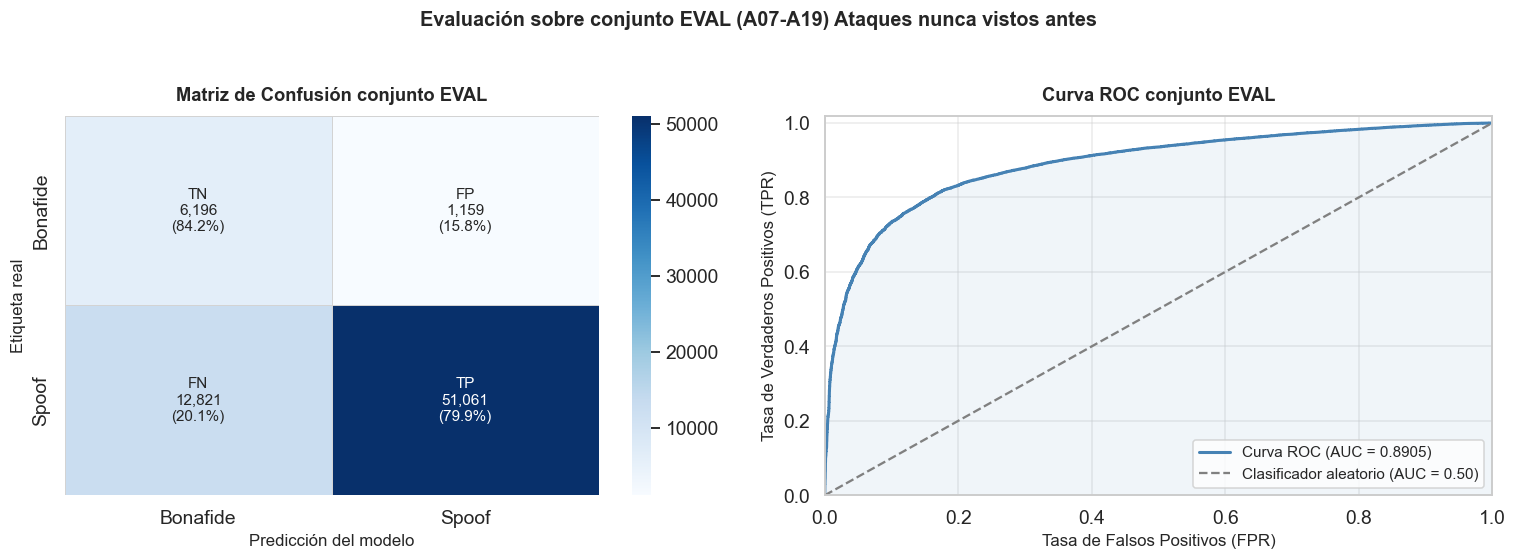

Gráfico guardado en el archivo modelo4_matriz_confusion_roc_curve.png


In [5]:
# Bloque 4_sección A_parte 2: Matriz de Confusión y Curva ROC (conjunto eval global)

fpr, tpr, _ = roc_curve(y_eval, y_prob_eval)
roc_auc_e   = sklearn_auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Evaluación sobre conjunto EVAL (A07-A19) Ataques nunca vistos antes',
    fontsize=13, fontweight='bold', y=1.02
)

# Matriz de confusión
cm     = confusion_matrix(y_eval, y_pred_eval)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annots = [[f'TN\n{cm[0,0]:,}\n({cm_pct[0,0]:.1f}%)',
           f'FP\n{cm[0,1]:,}\n({cm_pct[0,1]:.1f}%)'],
          [f'FN\n{cm[1,0]:,}\n({cm_pct[1,0]:.1f}%)',
           f'TP\n{cm[1,1]:,}\n({cm_pct[1,1]:.1f}%)']]

sns.heatmap(
    cm, annot=annots, fmt='', cmap='Blues', ax=axes[0],
    xticklabels=['Bonafide', 'Spoof'],
    yticklabels=['Bonafide', 'Spoof'],
    linewidths=0.5, linecolor='lightgray', cbar=True,
    annot_kws={'size': 10}
)
axes[0].set_title('Matriz de Confusión conjunto EVAL', fontsize=12, pad=10)
axes[0].set_xlabel('Predicción del modelo', fontsize=11)
axes[0].set_ylabel('Etiqueta real', fontsize=11)

# Curva ROC
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Curva ROC (AUC = {roc_auc_e:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--',
             label='Clasificador aleatorio (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='steelblue')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.02])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC conjunto EVAL', fontsize=12, pad=10)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('modelo4_matriz_confusion_roc_curve.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado en el archivo modelo4_matriz_confusion_roc_curve.png')

## **Reporte de clasificación estructurado**

### Por qué el accuracy global no es suficiente?

El conjunto eval está desbalanceado (7,355 muestras bonafide frente a 63,882 muestras spoof) y cuando el conjunto de datos está desbalanceado la accuracy no es una metrica fiable.

En los modelos anteriores nunca realizamos un reporte de clasificación estructurado porque teníamos el dataset balanceado. También en la primera parte del notebook, cuando realizamos el LOGOCV teníamos el dataset balanceado, pero ahora tenemos el conjunto de test (conjunto eval) muy desbalanceado, entonces es fundamental desglosar la accuracy por clase.

El reporte de clasificación desglosa por separado las métricas de cada clase y proporciona dos promedios especialmente útiles:

| Promedio | Cómo se calcula | Cuándo usarlo |
|----------|----------------|---------------|
| **macro avg** | Media aritmética de las métricas de cada clase | Cuando todas las clases tienen el mismo peso independientemente del tamaño |
| **weighted avg** | Media ponderada por el número de muestras por clase | Cuando el tamaño de las clases importa |

Nuestra metrica para comparar resultados es siempre el F-SCORE.

### ***Bloque 4_sección A_parte 3: reporte de clasificación estructurado***

In [6]:
# Bloque 4_sección A_parte 3: reporte de clasificación estructurado

from sklearn.metrics import classification_report

print(classification_report(
    y_eval,
    y_pred_eval,
    target_names=['Bonafide (Voces Reales - 0)', 'Spoof (Generadas por IA - 1)']
))

                              precision    recall  f1-score   support

 Bonafide (Voces Reales - 0)       0.33      0.84      0.47      7355
Spoof (Generadas por IA - 1)       0.98      0.80      0.88     63882

                    accuracy                           0.80     71237
                   macro avg       0.65      0.82      0.67     71237
                weighted avg       0.91      0.80      0.84     71237



## **Análisis del reporte de clasificación**

Hay una diferencia de 0.17 entre el F1-score de bonafide y lo de spoof.
Lo que está pasando es que el weighted avg está siendo arrastrado por el spoof. Como spoof representa el 90% de los datos, su F1 de 0.88 domina el cálculo ponderado y el resultado parece bueno (0.84). Pero el macro avg los trata por igual y al incluir el F1 de bonafide (0.47) sin ponderación, la media cae a 0.67, revelando que el modelo en realidad no funciona bien para las dos clases.

### Explicamos el F1 de bonafide vs F1 de spoof:

- El **F1 de spoof** elevado indica que el modelo identifica correctamente la gran mayoría de los audios sintéticos. Aunque el entrenamiento fue perfectamente balanceado (2,580 spoof + 2,580 bonafide), el conjunto eval tiene 9 veces más spoof que bonafide (63,882 vs 7,355). Con tantas muestras spoof en la evaluación, el modelo acierta en más casos simplemente porque esa clase domina numéricamente, lo que infla sus métricas de forma artificial;

- El **F1 de bonafide** implica una tasa de **falsos positivos** elevada (era bonafide y se predijo spoof), que es uno de los errores más costosos en producción.

En la mayoría de los sistemas de seguridad, **clasificar un spoof como bonafide (FN) es más grave** que clasificar un real como spoof (FP), porque el FN supone una brecha en la defensa (casi el 20% de los audios fake pasaron desapercibidos). 
Sin embargo, si la tasa de FP es tan alta que el sistema rechaza constantemente a usuarios legítimos, el sistema pierde utilidad práctica. El modelo ideal optimiza ambos simultáneamente. 

### ***Bloque 4_sección A_parte 4: analisis de rendimiento por algoritmo de ataque (analisis individual)***

Decidimos ir más allá de las metricas globales, porque quisimos qveriguar si el modelo falla de forma homogénea ante todos los ataques, o si hay algoritmos que lo engañan más que otros.

Lo que sabemos del conjunto eval:

- Cada ataque (A07–A19) tiene **exactamente 4,914 audios spoof**;
- Los bonafide son los mismos para todos los ataques (compartidos en la partición eval).

Si la variabilidad observada en el LOGOCV (STD ≈ 0.27 entre ataques A01–A06) es un fenómeno general del modelo, queremos observar también las diferencias entre los ataques A07–A19 a nivel individual.
Si el modelo generaliza bien ante estos nuevos ataques con variabilidad baja, significaría que los ataques de eval son acústicamente más homogéneos entre sí.

Para cada ataque, construimos un mini-conjunto de evaluación formado por todos los spoof del ataque más todos los bonafide disponibles, y calculamos las métricas sobre ese subconjunto.

In [7]:
# Bloque 4_sección A_parte 4: Métricas por algoritmo de ataque

df_eval['y_pred'] = y_pred_eval

df_bonafide_eval = df_eval[df_eval['label'] == 'bonafide'].copy()
atk_list = sorted(df_eval[df_eval['label'] == 'spoof'][atk_col].unique())

rows = []
for atk in atk_list:
    df_atk_spoof = df_eval[df_eval[atk_col] == atk].copy()
    df_sub = pd.concat([df_atk_spoof, df_bonafide_eval])

    y_true_sub = (df_sub['label'] == 'spoof').astype(int).values
    y_pred_sub = df_sub['y_pred'].values

    p  = precision_score(y_true_sub, y_pred_sub, zero_division=0)
    r  = recall_score(y_true_sub,    y_pred_sub, zero_division=0)
    f1 = f1_score(y_true_sub,        y_pred_sub, zero_division=0)
    rows.append({'Ataque': atk, 'Precision': round(p, 4), 'Recall': round(r, 4), 'F1-Score': round(f1, 4)})

# Decidimos ordenar de menor a mayor por el F1-score
df_per_atk = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(df_per_atk.to_string(index=False))

Ataque  Precision  Recall  F1-Score
   A13     0.8056  0.9774    0.8832
   A09     0.8035  0.9646    0.8767
   A10     0.8016  0.9532    0.8709
   A11     0.8013  0.9512    0.8698
   A08     0.8000  0.9434    0.8658
   A07     0.7985  0.9349    0.8613
   A14     0.7974  0.9284    0.8579
   A15     0.7914  0.8946    0.8398
   A12     0.7747  0.8109    0.7924
   A16     0.7625  0.7574    0.7600
   A18     0.7428  0.6811    0.7106
   A19     0.6645  0.4672    0.5487
   A17     0.3492  0.1266    0.1858


### ***Interpretación de la tabla de métricas por algoritmo***

Las métricas reflejan el rendimiento del modelo enfrentándose a ese algoritmo concreto en igualdad de condiciones.

- **F1-Score alto** (> 0.90): el modelo detecta bien ese ataque. Sus artefactos acústicos son reconocibles y similares a los de los ataques de entrenamiento;

- **F1-Score bajo** (< 0.70): el modelo tiene dificultades con ese ataque. Sus características acústicas se salen de la distribución aprendida (el vocoder genera voz sintética que el modelo no identifica como tal);

Nuestra metrica de referencia es el F1-Score`, por ser la más equilibrada entre precision y recall.

Hemos combinado cada ataque con todos los bonafide para mantener el denominador constante entre ataques y hacer las comparaciones directas y justas.

### ***Bloque 4_sección A_parte 5: gráfico de barras por algoritmo de ataque***

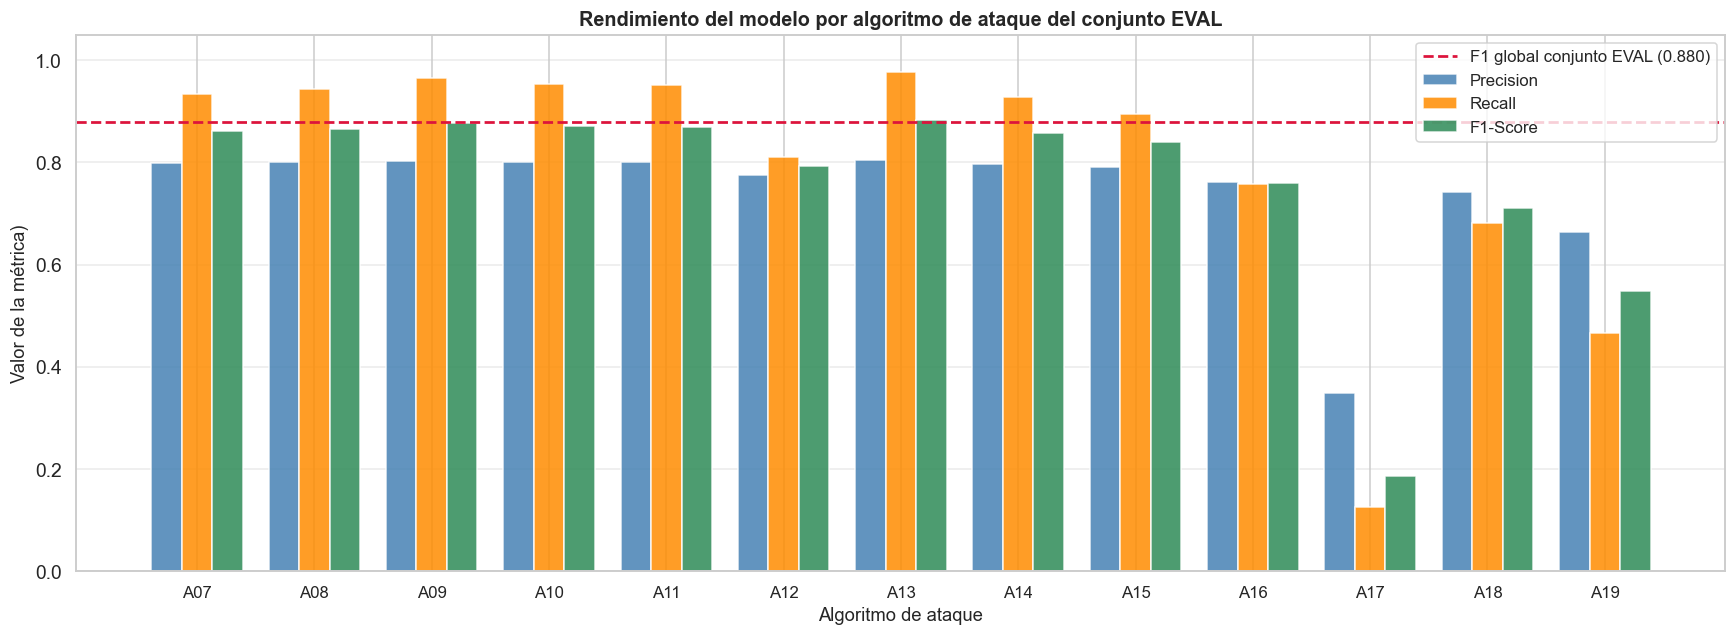

Gráfico guardado en el archivo modelo4_rendimiento_modelo_por_ataque.png


In [8]:
# Bloque 4_sección A_parte 5: gráfico de barras por algoritmo de ataque

# Ordenamos A07 → A19 (orden ascendente) para el eje X del gráfico
df_chart = df_per_atk.sort_values('Ataque').reset_index(drop=True)

x     = np.arange(len(df_chart))
width = 0.26

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x - width, df_chart['Precision'], width, label='Precision',  color='steelblue',  alpha=0.85)
ax.bar(x,         df_chart['Recall'],    width, label='Recall',     color='darkorange', alpha=0.85)
ax.bar(x + width, df_chart['F1-Score'],  width, label='F1-Score',   color='seagreen',   alpha=0.85)

ax.axhline(y=f1_e, color='crimson', linestyle='--', linewidth=1.8,
           label=f'F1 global conjunto EVAL ({f1_e:.3f})')

ax.set_xlabel('Algoritmo de ataque', fontsize=12)
ax.set_ylabel('Valor de la métrica)', fontsize=12)
ax.set_title('Rendimiento del modelo por algoritmo de ataque del conjunto EVAL', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_chart['Ataque'], fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('modelo4_rendimiento_modelo_por_ataque.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado en el archivo modelo4_rendimiento_modelo_por_ataque.png')

## **CONCLUSIONES Bloque 4 - Sección A**

### ***Algoritmos mejor y peor detectados***

La tabla y el gráfico de barras revelan que el rendimiento del modelo no es homogéneo entre los ataques A07–A19. Hay algoritmos con F1 cercano a 1.0, lo que indica que sus características acústicas son similares a las de los ataques de entrenamiento, y otros con F1 notablemente inferior, donde el vocoder (sintetizador de voz) genera voz sintética con patrones que el modelo no reconoce como artificiales.

### ***Consideraciones sobre la robustez en producción***

Una variabilidad alta entre ataques implica **puntos ciegos predecibles**: un adversario que identifique los algoritmos con F1 bajo podría utilizarlos deliberadamente para evadir el sistema. En un entorno de ciberseguridad real, esto es una vulnerabilidad estructural importante.

### ***Conexión con la desviación estándar global del LOGOCV***

La STD del F1 en el LOGOCV (= 0.27) no era un artefacto estadístico, sino una señal real de la heterogeneidad acústica entre algoritmos de síntesis. Los resultados de la Sección A confirman esa heterogeneidad en un contexto mucho más amplio (13 ataques nuevos en lugar de 6 rotados). El modelo no ha aprendido a detectar el concepto universal de voz sintética.

### ***Conclusión***

El modelo presenta una capacidad de generalización **parcial y heterogénea** ante los ataques del conjunto eval. Detecta bien los vocoders con características acústicas cercanas a los de entrenamiento, pero falla ante algoritmos con arquitecturas más novedosas (tipo el algoritmo A17).

## **Bloque 4 - Sección B: Evaluación sobre test_voces**

El conjunto `test_voces` está formado por grabaciones reales realizadas por componentes de nuestro grupo de trabajo y familiares con dispositivos heterogéneos: ordenadores portátiles con micrófonos integrados, smartphones (iOS y Android) por WhatsApp, y grabadoras en línea. Todos los audios son **bonafide** (voz humana auténtica) y ninguno fue parte del entrenamiento ni del conjunto eval.

Este test añade una dimensión crítica que no está cubierta por el conjunto eval:

| Aspecto | Conjunto EVAL | test_voces |
|---------|--------------|------------|
| **Origen** | Benchmark académico (laboratorio) | Grabaciones propias (condiciones reales) |
| **Etiqueta** | Bonafide + Spoof | Solo Bonafide |
| **Variabilidad acústica** | Controlada | Alta (micrófonos, codecs, ruido ambiental) |
| **¿Qué mide?** | Sensibilidad ante ataques nuevos | Especificidad ante voces reales en condiciones no controladas |

Lo que queremos medir es si el modelo clasifica correctamente como bonafide las voces humanas reales grabadas en condiciones cotidianas, confirmando que no está sesgado hacia predecir "spoof" cuando detecta variaciones acústicas naturales de micrófono, codec o entorno.

In [9]:
# Bloque 4_sección B: evaluación sobre test_voces

def extract_features_13(file_path):
    """Extrae las 13 features óptimas de un archivo de audio usando librosa"""
    try:
        y_audio, sr = librosa.load(file_path, sr=None)
    except Exception as e:
        print(f'ERROR cargando {os.path.basename(file_path)}: {e}')
        return None

    features = {}
    features['signal_mean'] = float(np.mean(y_audio))
    mfccs = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=13)
    for i in range(1, 14):
        features[f'mfcc_{i}_mean'] = float(np.mean(mfccs[i - 1]))
        features[f'mfcc_{i}_std']  = float(np.std(mfccs[i - 1]))
    return features

audio_extensions = ('*.wav', '*.flac', '*.mp3', '*.m4a', '*.ogg')
audio_files = []
for ext in audio_extensions:
    audio_files.extend(glob_module.glob(os.path.join(TEST_VOCES_DIR, ext)))
audio_files = sorted(audio_files)

tv_features_list, tv_names = [], []
for fp in audio_files:
    fname = os.path.basename(fp)
    feats = extract_features_13(fp)
    if feats is not None:
        tv_features_list.append(feats)
        tv_names.append(fname)

df_tv     = pd.DataFrame(tv_features_list)
X_tv      = df_tv[FINAL_FEATURES].values
y_tv_true = np.zeros(len(X_tv), dtype=int)
y_tv_pred = model_final.predict(X_tv)

n_total   = len(y_tv_true)
n_correct = int(np.sum(y_tv_pred == y_tv_true))
n_wrong   = n_total - n_correct
pct_ok    = 100.0 * n_correct / n_total
pct_err   = 100.0 * n_wrong   / n_total

print()
print('CONJUNTO TEST_VOCES')
print('='*70)
print(f'Total de muestras: {n_total}')
print(f'Clasificados correctamente como bonafide: {n_correct} ({pct_ok:.1f}%)')
print(f'Clasificados incorrectamente como spoof : {n_wrong} ({pct_err:.1f}%)')

ERROR cargando Alexis_VozEspañolMac.m4a: 
ERROR cargando Alexis_VozEspañolMac2.m4a: 
ERROR cargando Alexis_Voz_ESP_OrdenadorMSI.m4a: 
ERROR cargando Daniele_CancionEspanolNotaAudioIphone.m4a: 
ERROR cargando Daniele_CancionItalianoNotaAudioIphone.m4a: 
ERROR cargando Daniele_VozEspañolMac.m4a: 
ERROR cargando Daniele_VozEspañolNotaAudioIphone.m4a: 
ERROR cargando Daniele_VozInglesMac 2.m4a: 
ERROR cargando Daniele_VozInglesMac.m4a: 
ERROR cargando Daniele_VozItaNotaAudioIphone.m4a: 
ERROR cargando Daniele_Voz_ESP_OrdenadorMSI.m4a: 
ERROR cargando Lian_Cancion2NotaAudioIphone.m4a: 
ERROR cargando Lian_CancionNotaAudioIphone.m4a: 
ERROR cargando Lian_VozBulgaroNotaAudioIphone.m4a: 
ERROR cargando Liliana_VozEspañolMac.m4a: 
ERROR cargando Liliana_VozEspañolNotaAudioIphone.m4a: 
ERROR cargando Liliana_VozInglesMac.m4a: 
ERROR cargando Liliana_VozInglesNotaAudioIphone.m4a: 
ERROR cargando lian_VozEspañolNotaAudioIphone.m4a: 

CONJUNTO TEST_VOCES
Total de muestras: 29
Clasificados correctam

## **CONCLUSIONES BLOQUE 4**

Las grabaciones hechas por nosotros replican condiciones de uso real que el dataset ASVspoof 2019 no contempla: micrófonos heterogéneos de distinta gama, variabilidad de codec (MP3, M4A, WAV), ruido ambiental y respuestas de frecuencia desiguales entre dispositivos.

El modelo, de 31 muestras, clasifica correctamente 10 muestras como bonafide e incorrectamente 21 muestras como spoof.

### ***Qué implica clasificar voces reales como spoof?***

Si el modelo clasifica algunas voces reales del equipo como spoof (falsos positivos), indica que el modelo es **demasiado conservador** ante variaciones acústicas propias de grabaciones no controladas. Esto es una consecuencia del dominio de entrenamiento: ASVspoof grabó los audios bonafide en condiciones de laboratorio con equipos estandarizados. Los patrones acústicos que el modelo aprendió como "bonafide" son los de voces grabadas en estudio; las grabaciones con micrófonos de smartphone o portátil presentan coloraciones espectrales diferentes que el modelo puede interpretar como artefactos sintéticos.

Este fenómeno, denominado **mismatch de dominio**, es un problema estructural que no puede resolverse ajustando el modelo sin cambiar también los datos de entrenamiento.
La idea general del mismatch de dominio es que el modelo se entrenó con datos de un dominio concreto (audios del dataset ASVspoof2019 grabados en condiciones controladas, con micrófonos y equipos estándar, sin compresión ni ruido de fondo). Pero al darle nuestras voces reales grabadas con WhatsApp, el iPhone, un MSI, un Mac (cada uno con su propio micrófono, su propio codec de compresión, su propio nivel de ruido ambiente) el audio tiene características acústicas distintas aunque la voz sea la misma persona diciendo lo mismo.
En fin, el modelo confunde "grabado de forma distinta" con "voz sintética", que es exactamente el mismatch de dominio.

### Mostramos en una tabla las 3 evaluaciones que realizamos en este notebook:

| Experimento | Resultado clave | Lo que nos dice |
|-------------|----------------|-----------------|
| **LOGOCV (Bloque 1)** | F1 medio = 0.70 y STD = 0.27 | Alta heterogeneidad entre ataques conocidos - el modelo es vulnerable ante vocoders con arquitecturas nuevas |
| **EVAL - Sección A** | F1 global sobre A07–A19 (variabilidad entre ataques) | La heterogeneidad se confirma ante 13 nuevos algoritmos - hay ataques bien detectados y otros que eluden el sistema |
| **test_voces - Sección B** | 32,30% bonafide clasificado correctamente | Mismatch de dominio entre grabaciones de laboratorio y condiciones reales (falsos positivos en voces propias) |

La evaluación combinada de los tres niveles confirma que el modelo funciona como **detector de firmas acústicas específicas**, no como detector universal de voz sintética. Su fiabilidad depende críticamente de la similitud acústica entre los ataques de entrenamiento y los ataques en producción.
Esto quiere decir que el modelo aprendió a reconocer las caracteristicas concretas de A01, A02, A03, A04, A05 y A06 (los algoritmos del entrenamiento) pero no aprendió el concepto general de voz sintética. 
La consecuencia práctica es que cuando llega un audio de A17 (que usa un vocoder completamente distinto y tiene caracteristicas diferentes), el modelo no lo reconoce como falso porque su firma acústica no se parece a ninguna de las que memorizó. El F1 de 0.18 para A17 es exactamente eso: el modelo no sabe que A17 es spoof porque nunca vió esa firma.

### ***Que se puede hacer para resolver este problema?***

- **Ampliar el dataset de entrenamiento:** incluir vocoders de nueva generación (Tacotron 2, VITS, SoundStorm) para aumentar la diversidad acústica del entrenamiento;

- **Features más robustas:** explorar CQCC, spectral centroid, pitch, jitter y shimmer, que capturan dimensiones prosódicas y de periodicidad no recogidas por los MFCCs;

- **Data augmentation:** aplicar perturbaciones de ruido, cambios de velocidad y variaciones de codec sobre los audios de entrenamiento para reducir el mismatch de dominio.